# Detectability Diagnostics

This notebook compares non-defense detectability signals against attack
effectiveness for every paper value selector. It distinguishes dataset,
poison rate, sampling strategy, and target-feature policy.

Current artifact diagnostics are preferred over historical aggregate
tables. The current experiment matrix contains 1%, 3%, and 5% poisoning
under random and distribution-based sampling.

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_ROOT = PROJECT_ROOT / "results"
MPLCONFIGDIR = PROJECT_ROOT / "build" / "matplotlib"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis.result_catalog import (
    DEFENSE_LABELS,
    DEFENSE_METHOD_ORDER,
    PMSB_SAMPLING_STRATEGIES,
    SAMPLING_ORDER,
    VALUE_LABELS,
    VALUE_ORDER,
    add_display_columns,
    comparison_coverage,
    discover_attack_artifacts,
    load_attack_summaries,
    load_detector_metrics,
    load_defense_metrics,
    load_detectability_score_metrics,
    load_detectability_summaries,
    merge_effectiveness,
    preferred_detector_metrics,
    preferred_defense_metrics,
)

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid", context="notebook")

PAPER_VALUE_SELECTORS = [
    "argmin_Nv_sum_abs_shap",
    "min_population_new",
    "low_shap_signed",
    "frequency_bounded",
    "frequency_bounded_signed_shap",
    "quantile_05",
    "quantile_50",
    "quantile_95",
    "benign_prototype",
    "corr_count_abs_shap",
]
PAPER_SAMPLINGS = ["random", "distribution_based_distance"]
PAPER_TARGET_FEATURES = ["problem_space_conservative"]
FOCUS_DATASETS = ["EMBER2018", "EMBER2024 WIN64"]
FOCUS_POISON_RATES = [0.01, 0.03, 0.05]

print("Project root:", PROJECT_ROOT)
print("Results root:", RESULTS_ROOT)

Project root: /Users/falcon/Machine Learning/Defense GMM-Maha
Results root: /Users/falcon/Machine Learning/Defense GMM-Maha/results


## Analysis Controls

In [2]:
def filter_paper_rows(df):
    if df.empty:
        return df.copy()
    out = df[
        df["dataset_label"].isin(FOCUS_DATASETS)
        & df["sampling_strategy"].isin(PAPER_SAMPLINGS)
        & df["value_selector"].isin(PAPER_VALUE_SELECTORS)
        & df["target_features"].isin(PAPER_TARGET_FEATURES)
    ].copy()
    if FOCUS_POISON_RATES is not None:
        wanted = np.asarray(FOCUS_POISON_RATES, dtype=float)
        out = out[
            out["poison_rate_train"].map(
                lambda value: np.isclose(value, wanted, atol=1e-12).any()
                if pd.notna(value)
                else False
            )
        ]
    return add_display_columns(out)


def ordered_pivot(df, *, index, columns, values, aggfunc="mean"):
    pivot = df.pivot_table(
        index=index,
        columns=columns,
        values=values,
        aggfunc=aggfunc,
        observed=True,
    )
    if columns in {"value_selector", "selector_label"}:
        labels = [VALUE_LABELS[value] for value in PAPER_VALUE_SELECTORS]
        pivot = pivot.reindex(columns=[label for label in labels if label in pivot.columns])
    return pivot.dropna(how="all", axis=0).dropna(how="all", axis=1)


def show_heatmap(pivot, title, *, cmap="viridis", fmt=".1f", center=None, vmin=None, vmax=None):
    if pivot.empty:
        print("No rows for", title)
        return
    width = max(9, 0.82 * pivot.shape[1] + 2.5)
    height = max(3.2, 0.55 * pivot.shape[0] + 2.0)
    fig, ax = plt.subplots(figsize=(width, height))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        center=center,
        vmin=vmin,
        vmax=vmax,
        linewidths=0.5,
        linecolor="white",
        ax=ax,
    )
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

## Load Effectiveness, Artifacts, And Diagnostics

In [3]:
attack_df_all = load_attack_summaries(RESULTS_ROOT)
artifact_df_all = discover_attack_artifacts(RESULTS_ROOT)
diagnostic_df_all = load_detectability_summaries(
    RESULTS_ROOT, include_legacy_aggregate=True
)
score_df_all = load_detectability_score_metrics(
    RESULTS_ROOT, include_legacy_aggregate=True
)

attack_df = filter_paper_rows(attack_df_all)
artifact_df = filter_paper_rows(artifact_df_all)
diagnostic_df = filter_paper_rows(diagnostic_df_all)
score_df = filter_paper_rows(score_df_all)
merged_df = merge_effectiveness(diagnostic_df, attack_df)

print("Attack rows:", len(attack_df))
print("Attack artifact records:", len(artifact_df))
print("Diagnostics-ready artifacts:", int(artifact_df["diagnostics_ready"].sum()))
print("Diagnostic summaries:", len(diagnostic_df))
print("Diagnostic score rows:", len(score_df))
if not diagnostic_df.empty:
    display(
        diagnostic_df.groupby(
            ["dataset_label", "poison_rate_label", "sampling_strategy", "diagnostic_source"],
            dropna=False,
        )
        .size()
        .rename("rows")
        .reset_index()
    )

Attack rows: 120
Attack artifact records: 120
Diagnostics-ready artifacts: 10
Diagnostic summaries: 0
Diagnostic score rows: 0


## Coverage And Missing Diagnostics

`artifact_available=True` means diagnostics can be generated directly
with the existing files. Summary-only runs still need
`--save-attack-artifacts --save-defense-inputs` before diagnostics can be
computed.

In [4]:
attack_coverage = comparison_coverage(
    attack_df,
    datasets=FOCUS_DATASETS,
    samplings=PAPER_SAMPLINGS,
    target_features=PAPER_TARGET_FEATURES,
)
display(attack_coverage)

keys = [
    "dataset_label",
    "sampling_strategy",
    "poison_rate_train",
    "feature_selector",
    "value_selector",
    "target_features",
]
available = artifact_df[
    artifact_df["diagnostics_ready"]
][keys + ["artifact_dir"]].drop_duplicates(keys)
artifact_status = artifact_df[
    keys + ["diagnostics_ready", "missing_diagnostic_files"]
].drop_duplicates(keys)
completed = diagnostic_df[keys + ["diagnostic_source"]].drop_duplicates(keys)
missing_diagnostics = (
    attack_df[keys + ["poison_rate_label", "summary_df_path"]]
    .drop_duplicates(keys)
    .merge(artifact_status, on=keys, how="left")
    .merge(available, on=keys, how="left")
    .merge(completed, on=keys, how="left")
)
missing_diagnostics["artifact_available"] = missing_diagnostics["artifact_dir"].notna()
missing_diagnostics = missing_diagnostics[
    missing_diagnostics["diagnostic_source"].isna()
].sort_values(["dataset_label", "poison_rate_train", "sampling_strategy", "value_selector"])

print("Attack configurations without matching diagnostics:", len(missing_diagnostics))
display(
    missing_diagnostics[
        [
            "dataset_label",
            "poison_rate_label",
            "sampling_strategy",
            "value_selector",
            "artifact_available",
            "missing_diagnostic_files",
            "artifact_dir",
        ]
    ].head(100)
)

,dataset_label,poison_rate_label,sampling_strategy,target_features,selectors,rows,watermark_sizes
0,EMBER2018,1%,distribution_based_distance,problem_space_conservative,10,10,[17]
1,EMBER2018,1%,random,problem_space_conservative,10,10,[17]
2,EMBER2018,3%,distribution_based_distance,problem_space_conservative,10,10,[17]
3,EMBER2018,3%,random,problem_space_conservative,10,10,[17]
4,EMBER2018,5%,distribution_based_distance,problem_space_conservative,10,10,[17]
5,EMBER2018,5%,random,problem_space_conservative,10,10,[17]
6,EMBER2024 WIN64,1%,distribution_based_distance,problem_space_conservative,10,10,[19]
7,EMBER2024 WIN64,1%,random,problem_space_conservative,10,10,[19]
8,EMBER2024 WIN64,3%,distribution_based_distance,problem_space_conservative,10,10,[19]
9,EMBER2024 WIN64,3%,random,problem_space_conservative,10,10,[19]


Attack configurations without matching diagnostics: 120


,dataset_label,poison_rate_label,sampling_strategy,value_selector,artifact_available,missing_diagnostic_files,artifact_dir
20,EMBER2018,1%,distribution_based_distance,argmin_Nv_sum_abs_shap,False,"watermarked_X.npy, watermarked_y.npy",NaN
21,EMBER2018,1%,distribution_based_distance,benign_prototype,False,"watermarked_X.npy, watermarked_y.npy",NaN
22,EMBER2018,1%,distribution_based_distance,corr_count_abs_shap,False,"watermarked_X.npy, watermarked_y.npy",NaN
23,EMBER2018,1%,distribution_based_distance,frequency_bounded,False,"watermarked_X.npy, watermarked_y.npy",NaN
24,EMBER2018,1%,distribution_based_distance,frequency_bounded_signed_shap,False,"watermarked_X.npy, watermarked_y.npy",NaN
25,EMBER2018,1%,distribution_based_distance,low_shap_signed,False,"watermarked_X.npy, watermarked_y.npy",NaN
26,EMBER2018,1%,distribution_based_distance,min_population_new,False,"watermarked_X.npy, watermarked_y.npy",NaN
27,EMBER2018,1%,distribution_based_distance,quantile_05,False,"watermarked_X.npy, watermarked_y.npy",NaN
28,EMBER2018,1%,distribution_based_distance,quantile_50,False,"watermarked_X.npy, watermarked_y.npy",NaN
29,EMBER2018,1%,distribution_based_distance,quantile_95,False,"watermarked_X.npy, watermarked_y.npy",NaN


## Commands For Available Missing Artifacts

In [5]:
runnable = missing_diagnostics[missing_diagnostics["artifact_available"]].copy()
if runnable.empty:
    print("No complete artifacts are waiting for diagnostics.")
else:
    for artifact_dir in runnable["artifact_dir"].drop_duplicates():
        print(
            "python3 -m run_detectability_diagnostics "
            f'--artifact-dir "{artifact_dir}" --overwrite'
        )

python3 -m run_detectability_diagnostics --artifact-dir "/Users/falcon/Machine Learning/Defense GMM-Maha/results/ember2024/win64/Poison 0.5/distribution_based_distance-defense/attack_artifacts/ember2024_win64__lightgbm__shap_largest_abs__argmin_Nv_sum_abs_shap__problem_space_conservative" --overwrite
python3 -m run_detectability_diagnostics --artifact-dir "/Users/falcon/Machine Learning/Defense GMM-Maha/results/ember2024/win64/Poison 0.5/distribution_based_distance-defense/attack_artifacts/ember2024_win64__lightgbm__shap_largest_abs__benign_prototype__problem_space_conservative" --overwrite
python3 -m run_detectability_diagnostics --artifact-dir "/Users/falcon/Machine Learning/Defense GMM-Maha/results/ember2024/win64/Poison 0.5/distribution_based_distance-defense/attack_artifacts/ember2024_win64__lightgbm__shap_largest_abs__corr_count_abs_shap__problem_space_conservative" --overwrite
python3 -m run_detectability_diagnostics --artifact-dir "/Users/falcon/Machine Learning/Defense GMM-Mah

## Effectiveness Across Poison Rate And Sampling

This section remains useful even before every detectability diagnostic
is generated.

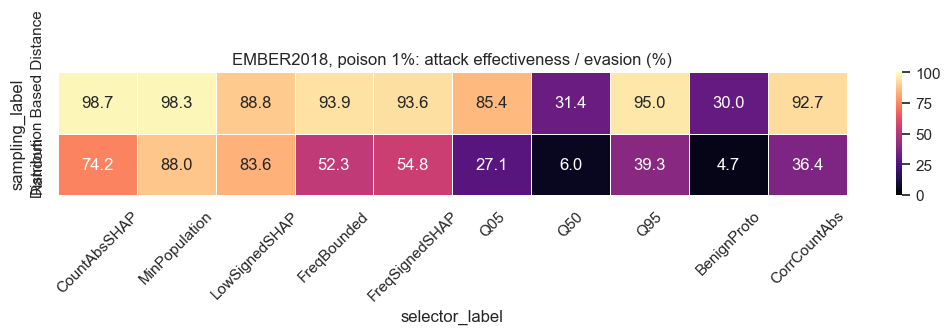

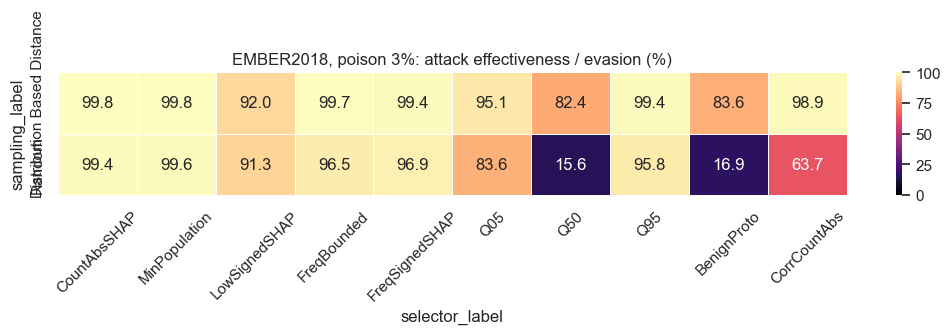

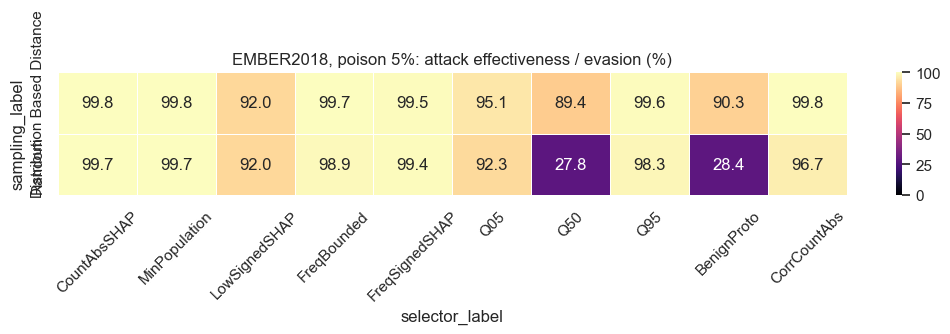

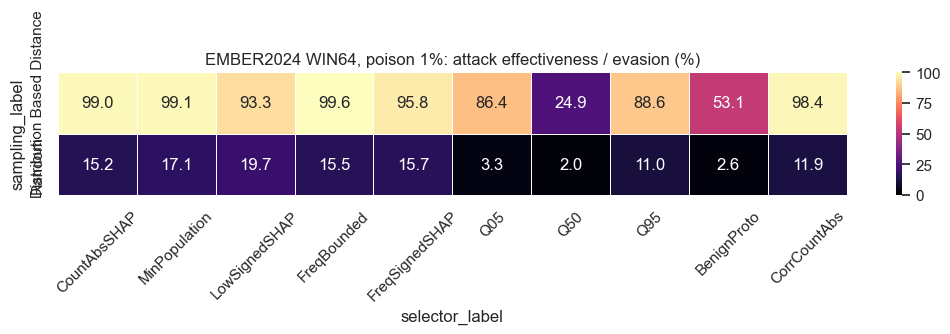

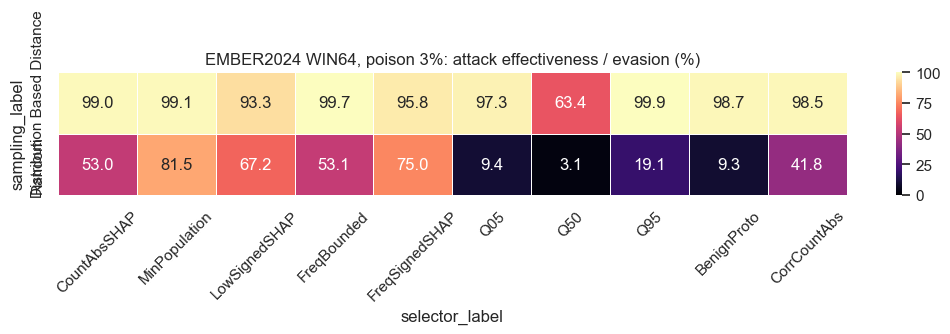

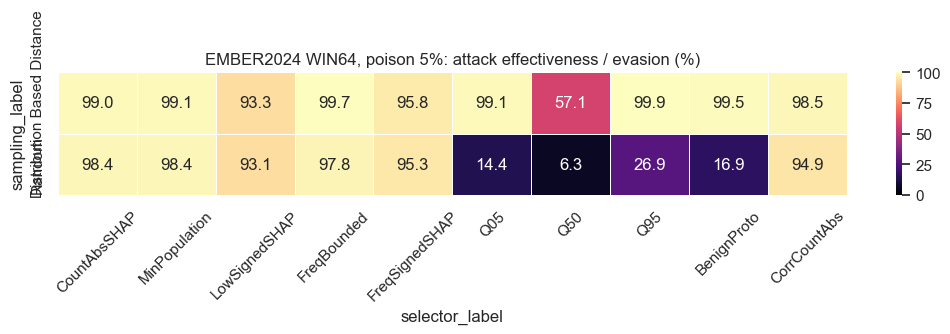

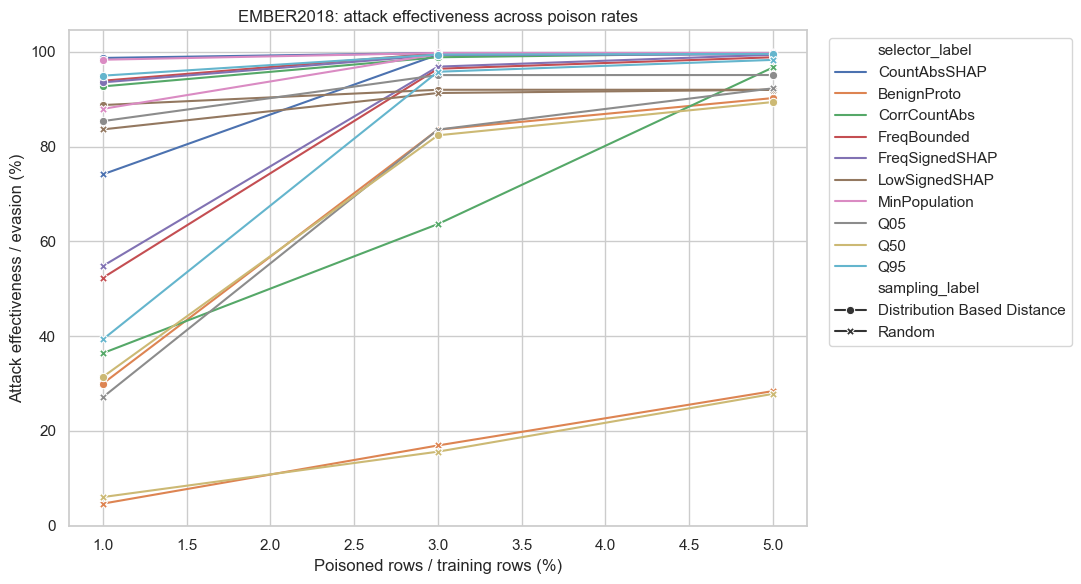

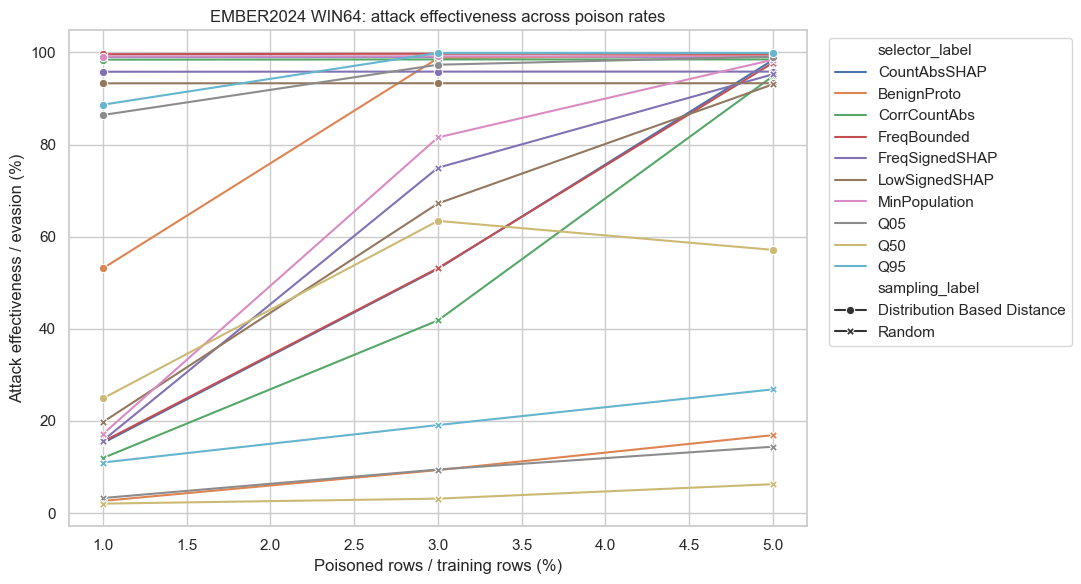

In [6]:
for (dataset, poison_label), group in attack_df.groupby(
    ["dataset_label", "poison_rate_label"], dropna=False
):
    pivot = ordered_pivot(
        group,
        index="sampling_label",
        columns="selector_label",
        values="attack_effectiveness_percent",
    )
    show_heatmap(
        pivot,
        f"{dataset}, poison {poison_label}: attack effectiveness / evasion (%)",
        cmap="magma",
        vmin=0,
        vmax=100,
    )

for dataset, group in attack_df.groupby("dataset_label"):
    fig, ax = plt.subplots(figsize=(11, 6))
    sns.lineplot(
        data=group,
        x="poison_rate_percent",
        y="attack_effectiveness_percent",
        hue="selector_label",
        style="sampling_label",
        markers=True,
        dashes=False,
        estimator="mean",
        errorbar=None,
        ax=ax,
    )
    ax.set_title(f"{dataset}: attack effectiveness across poison rates")
    ax.set_xlabel("Poisoned rows / training rows (%)")
    ax.set_ylabel("Attack effectiveness / evasion (%)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Detectability Heatmaps

Higher AUROC means stronger separation between poisoned and clean benign
rows. Trigger rarity and exact trigger matching assume knowledge of the
trigger and should be described as diagnostic or oracle-informed signals.
SHAP concentration and kNN trigger-subspace separation are less direct.

In [7]:
detectability_metrics = [
    ("marginal_neg_log10_frequency_sum", "Marginal rarity sum", "mako", ".1f"),
    ("trigger_rarity_score_auroc", "Trigger rarity AUROC", "crest", ".2f"),
    ("shap_trigger_abs_ratio_auroc", "SHAP concentration AUROC", "crest", ".2f"),
    ("knn_trigger_mean_distance_auroc", "kNN trigger-distance AUROC", "crest", ".2f"),
]

for (dataset, poison_label, sampling), group in diagnostic_df.groupby(
    ["dataset_label", "poison_rate_label", "sampling_strategy"], dropna=False
):
    for metric, title, cmap, fmt in detectability_metrics:
        if metric not in group or group[metric].notna().sum() == 0:
            continue
        pivot = ordered_pivot(
            group,
            index="feature_selector",
            columns="selector_label",
            values=metric,
        )
        show_heatmap(
            pivot,
            f"{dataset}, poison {poison_label}, {sampling}: {title}",
            cmap=cmap,
            fmt=fmt,
            vmin=0 if "auroc" in metric else None,
            vmax=1 if "auroc" in metric else None,
        )

## Effectiveness Versus Non-Defense Detectability

In [8]:
for metric, metric_title, _, _ in detectability_metrics:
    if merged_df.empty or metric not in merged_df:
        continue
    focus = merged_df.dropna(subset=["attack_effectiveness_percent", metric]).copy()
    if focus.empty:
        continue
    for (dataset, poison_label), group in focus.groupby(
        ["dataset_label", "poison_rate_label"], dropna=False
    ):
        fig, ax = plt.subplots(figsize=(9, 5.5))
        sns.scatterplot(
            data=group,
            x="attack_effectiveness_percent",
            y=metric,
            hue="selector_label",
            style="sampling_label",
            size="watermark_size",
            sizes=(60, 180),
            s=90,
            ax=ax,
        )
        ax.set_title(
            f"{dataset}, poison {poison_label}: effectiveness vs {metric_title}"
        )
        ax.set_xlabel("Attack effectiveness / evasion (%)")
        ax.set_ylabel(metric_title)
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

## Poison-Rate Detectability Comparison

In [9]:
if diagnostic_df.empty:
    print("No diagnostics available for poison-rate comparison.")
else:
    metric = "shap_trigger_abs_ratio_auroc"
    focus = diagnostic_df.dropna(subset=[metric]).copy()
    for dataset, group in focus.groupby("dataset_label"):
        fig, ax = plt.subplots(figsize=(11, 6))
        sns.lineplot(
            data=group,
            x="poison_rate_percent",
            y=metric,
            hue="selector_label",
            style="sampling_label",
            markers=True,
            dashes=False,
            estimator="mean",
            errorbar=None,
            ax=ax,
        )
        ax.set_title(f"{dataset}: SHAP detectability across poison rates")
        ax.set_xlabel("Poisoned rows / training rows (%)")
        ax.set_ylabel("SHAP concentration AUROC")
        ax.set_ylim(0, 1.02)
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

No diagnostics available for poison-rate comparison.


## Recall At A Suspicion Budget

In [10]:
if score_df.empty:
    print("No detectability score metrics available.")
else:
    for (dataset, poison_label, sampling), group in score_df.groupby(
        ["dataset_label", "poison_rate_label", "sampling_strategy"], dropna=False
    ):
        g = sns.relplot(
            data=group,
            x="top_percent",
            y="poison_recall",
            hue="selector_label",
            col="score_name",
            col_wrap=2,
            kind="line",
            marker="o",
            facet_kws={"sharex": True, "sharey": True},
            height=4,
            aspect=1.15,
        )
        g.set_axis_labels("Top suspicious rows removed (%)", "Poison recall")
        g.set_titles("{col_name}")
        g.fig.suptitle(
            f"{dataset}, poison {poison_label}, {sampling}: recall at budget",
            y=1.02,
        )
        for ax in g.axes.flat:
            ax.set_ylim(0, 1.02)
        plt.show()

No detectability score metrics available.


## Optional Export

In [11]:
SAVE_TABLES = False
if SAVE_TABLES:
    out_dir = RESULTS_ROOT / "tables"
    out_dir.mkdir(parents=True, exist_ok=True)
    attack_df.to_csv(out_dir / "paper_attack_effectiveness_for_detectability.csv", index=False)
    diagnostic_df.to_csv(out_dir / "paper_detectability_catalog.csv", index=False)
    merged_df.to_csv(out_dir / "paper_effectiveness_vs_detectability.csv", index=False)
    missing_diagnostics.to_csv(out_dir / "paper_missing_detectability_runs.csv", index=False)
    print("Saved tables to", out_dir)
else:
    print("SAVE_TABLES is False; no files written.")

SAVE_TABLES is False; no files written.
